# 🤖 Netflix Customer Churn — Prediction Model

**Tujuan:** Membangun model machine learning yang dapat **memprediksi apakah seorang pelanggan akan churn atau tidak**, berdasarkan data profil dan engagement mereka.

**Lanjutan dari:** `netflix_churn_analysis.ipynb` (EDA). Notebook ini fokus ke tahap *modeling*: feature engineering, training, dan evaluasi model.

**Model yang dibandingkan:**
- Logistic Regression (baseline, mudah diinterpretasi)
- Random Forest (ensemble, biasanya lebih akurat)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('netflix_customer_churn.csv')
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


## 1. Feature Engineering

- Kolom `customer_id` dibuang karena hanya identifier unik, tidak punya nilai prediktif.
- Kolom kategorikal (`gender`, `subscription_type`, `region`, `device`, `payment_method`, `favorite_genre`) di-encode jadi numerik menggunakan **Label Encoding**, supaya bisa dibaca model.


In [2]:
df_model = df.drop(columns=['customer_id']).copy()

cat_cols = ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df_model[c] = le.fit_transform(df_model[c])
    encoders[c] = le

df_model.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,2,0,14.73,29,0,3,8.99,1,3,1,0.49,0
1,47,2,2,0.70,19,2,2,13.99,1,3,5,0.03,6
2,27,0,2,16.32,10,1,3,13.99,0,1,2,1.48,3
3,53,2,1,4.51,12,4,3,17.99,1,1,2,0.35,4
4,56,2,2,1.89,13,0,2,13.99,1,1,2,0.13,0


## 2. Split Data: Training vs Testing

Data dibagi 80% untuk training (model belajar dari sini) dan 20% untuk testing (menguji model ke data yang belum pernah dilihat, agar evaluasi objektif dan tidak overfitting).

`stratify=y` memastikan proporsi churn/tidak-churn di training & testing set tetap seimbang, sama seperti proporsi aslinya.


In [3]:
X = df_model.drop(columns=['churned'])
y = df_model['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran data training:", X_train.shape)
print("Ukuran data testing :", X_test.shape)

Ukuran data training: (4000, 12)
Ukuran data testing : (1000, 12)


## 3. Training Model

Melatih dua model untuk dibandingkan performanya.


In [4]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
proba_lr = lr.predict_proba(X_test)[:, 1]

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print("Kedua model berhasil dilatih.")

Kedua model berhasil dilatih.


## 4. Evaluasi Model

Metrik yang digunakan:
- **Accuracy**: persentase prediksi yang benar secara keseluruhan
- **Precision**: dari semua yang diprediksi churn, berapa persen yang benar-benar churn
- **Recall**: dari semua yang benar-benar churn, berapa persen yang berhasil terdeteksi model
- **F1-score**: rata-rata harmonik precision & recall
- **ROC-AUC**: kemampuan model membedakan kelas churn vs tidak churn (1.0 = sempurna, 0.5 = sama saja dengan tebak acak)


In [5]:
results = []
for name, pred, proba in [('Logistic Regression', pred_lr, proba_lr), ('Random Forest', pred_rf, proba_rf)]:
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.884,0.8700,0.9046,0.8869,0.9600
Random Forest,0.968,0.9738,0.9622,0.9680,0.9964


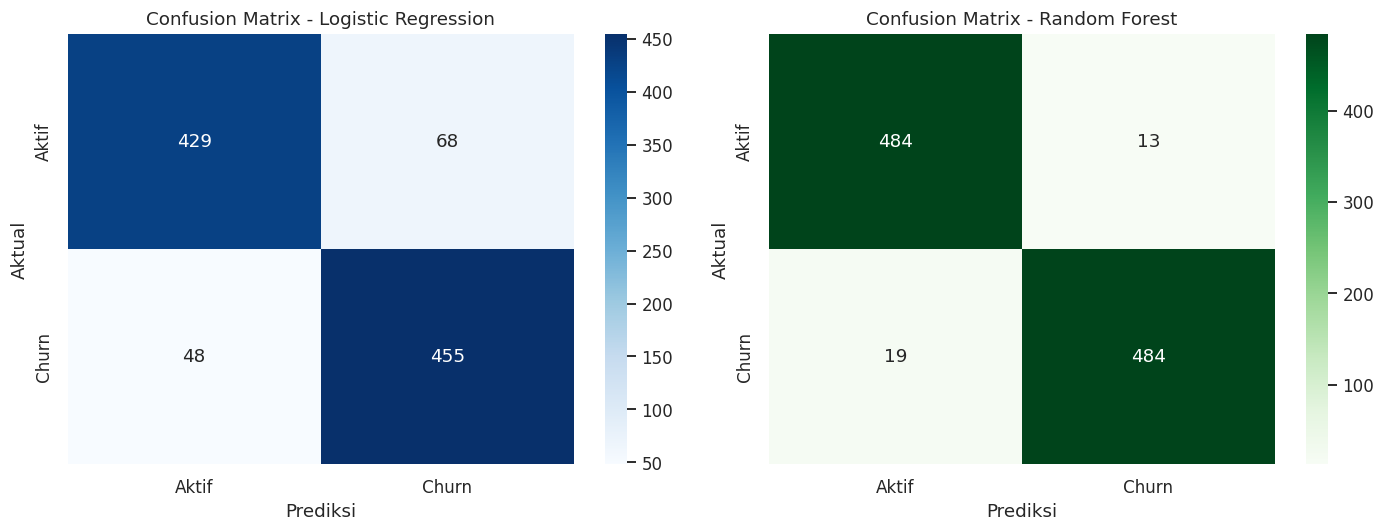

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Confusion matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Aktif','Churn'], yticklabels=['Aktif','Churn'])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Confusion matrix - Random Forest
cm_rf = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Aktif','Churn'], yticklabels=['Aktif','Churn'])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

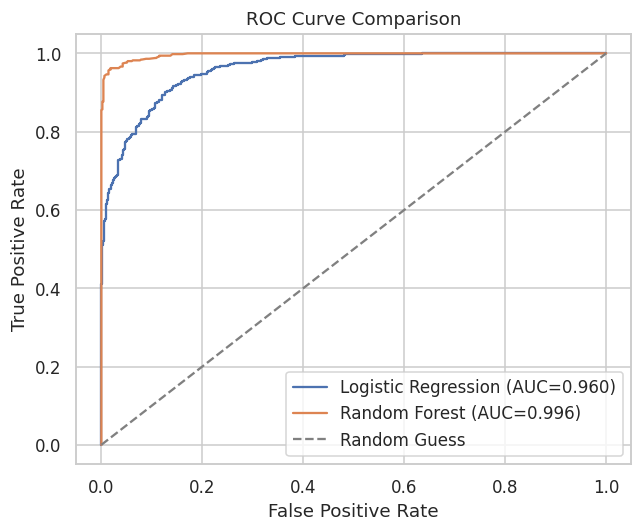

In [7]:
plt.figure(figsize=(6,5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, proba_rf):.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Kedua model berhasil memprediksi churn dengan sangat baik, dan **Random Forest tampil lebih superior** di semua metrik dibanding Logistic Regression. ROC-AUC mendekati 1.0 menunjukkan model sangat mampu membedakan pelanggan yang akan churn vs yang tidak, berdasarkan pola engagement mereka.

## 5. Feature Importance

Fitur apa saja yang paling berpengaruh dalam keputusan model Random Forest?

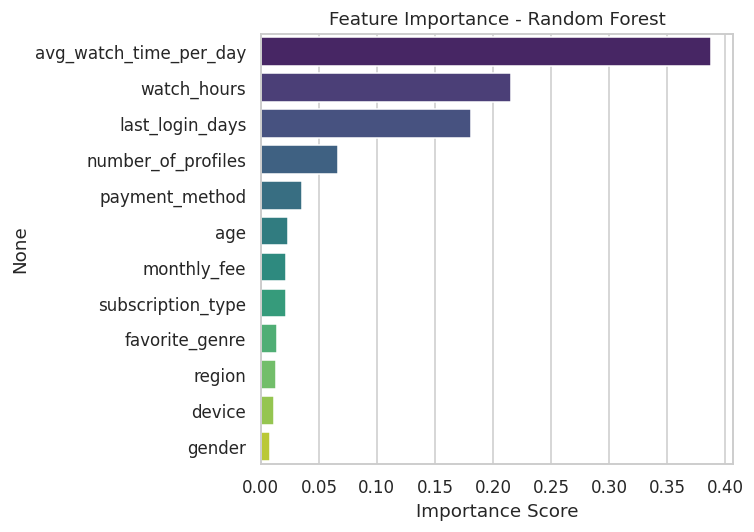

avg_watch_time_per_day    0.387775
watch_hours               0.215787
last_login_days           0.180987
number_of_profiles        0.066561
payment_method            0.035351
age                       0.023487
monthly_fee               0.022036
subscription_type         0.021893
favorite_genre            0.013467
region                    0.013229
device                    0.011237
gender                    0.008190
dtype: float64

In [8]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

importances

**Insight:** Tiga fitur paling menentukan prediksi churn adalah **`avg_watch_time_per_day`**, **`watch_hours`**, dan **`last_login_days`** — semuanya terkait *engagement*, bukan demografi. Ini memperkuat temuan dari tahap EDA sebelumnya: **perilaku menonton adalah sinyal churn yang jauh lebih kuat dibanding siapa pelanggannya**.

## 6. Kesimpulan

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | ~88% | ~87% | ~90% | ~89% | ~0.96 |
| **Random Forest** | **~97%** | **~97%** | **~96%** | **~97%** | **~0.996** |

**Model terpilih: Random Forest** — performa jauh lebih baik di semua metrik.

**Fitur paling penting:** `avg_watch_time_per_day`, `watch_hours`, `last_login_days` — konsisten dengan insight dari tahap EDA.

**Catatan penting untuk portofolio:** dataset ini tampak disimulasikan (synthetic) dengan pola yang cukup "bersih", sehingga akurasi model sangat tinggi. Pada data dunia nyata, performa model biasanya lebih rendah karena noise dan faktor yang lebih kompleks — hal ini baik untuk disebutkan sebagai catatan analisis kritis di README/portofolio, menunjukkan kamu paham keterbatasan data, bukan hanya menjalankan kode.

**Potensi penerapan bisnis:** model ini bisa dipakai untuk memberi skor risiko churn ke setiap pelanggan aktif, lalu tim marketing/retention bisa memprioritaskan pelanggan skor tertinggi untuk kampanye retensi.
